# Reading in GridRad-Severe Data 

```{image} ../thumbnails/grs_logo.png
:alt: GridRad-Severe Version 4.2 logo
:width: 200px
```

---

## Overview 
For some severe weather events in the Northeast U.S., there has been some observations of severe thunderstorms being locally enhanced by the dynamics of local topography by producing a local enhancement of severe reports or lightning. Past studies such as Wasula et al. (2002), LeBel et al. (2021) and Kramer et al. (2025) have analyzed more specific severe weather events across the central New York region and how some storms were enhanced in severity by processes such as valley channeling and vortex stretching from changes in terrain elevation. In this study, we seek to look at different severe thunderstorm events in the Northeast and study how local topography influences the intensity and distribution of these events. Similar to past studies such as Wasula et al. (2002), we will be looking at various different severe weather outbreaks and compare different synoptic environments and ambient background flows on the topography. Some examples of the differing synoptic-scale setups will be NW vs. SW flow and warm vs. cold season events. One database we will make use of in this research, along with several others, is GridRad-Severe, a gridded radar reflectivity dataset that contains radar data from over 100 stations across the CONUS. 

1. Prerequisites
2. Imports
3. Content
4. Summary
5. Conclusions
6. Resources and References

| Concepts | Importance | Notes |
| --- | --- | --- |
| [Intro to Cartopy](https://foundations.projectpythia.org/core/cartopy/cartopy) | Necessary | |
| [Understanding of NetCDF](https://foundations.projectpythia.org/core/data-formats/netcdf-cf) | Helpful | Familiarity with metadata structure |
| [Understanding of Xarray](https://foundations.projectpythia.org/core/xarray/) | Helpful | Analysis of gridded datasets |
| [Using Gridradpy Library](https://github.com/tsupinie/gridradpy) | Helpful | Specifically load in and use GridRad data | 
| Project management | Helpful | |

- **Time to learn**: About 50 minutes (10 minutes per subsection)

---

## Imports

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

In [2]:
file_path = '/nfs/mulholland_lab/acolgate/Research/nexrad_3d_v4_2_20230807T234500Z.nc' # Replace with the path to your file
ds = xr.open_dataset(file_path)

# Inspect the dataset to understand its structure, dimensions, and variables
print(ds)

<xarray.Dataset> Size: 542MB
Dimensions:                    (Sweep: 2114, Altitude: 29, Latitude: 1248,
                                Longitude: 1680, Index: 7007568, time: 1)
Coordinates:
  * Altitude                   (Altitude) float64 232B 0.5 1.0 1.5 ... 21.0 22.0
  * Latitude                   (Latitude) float64 10kB 24.01 24.03 ... 49.99
  * Longitude                  (Longitude) float64 13kB 251.5 251.5 ... 286.5
  * time                       (time) datetime64[ns] 8B 2023-08-07T23:45:00
Dimensions without coordinates: Sweep, Index
Data variables: (12/18)
    sweeps_merged              (Sweep) |S29 61kB ...
    Nradobs                    (Altitude, Latitude, Longitude) int8 61MB ...
    Nradecho                   (Altitude, Latitude, Longitude) int8 61MB ...
    index                      (Index) int32 28MB ...
    Reflectivity               (Index) float32 28MB ...
    wReflectivity              (Index) float32 28MB ...
    ...                         ...
    DifferentialRef

In [5]:
radar_ds = xr.open_dataset('/nfs/mulholland_lab/acolgate/Research/nexrad_3d_v4_2_20230807T234500Z.nc')
#print(radar_ds)

# Decode reflectivity grid (as in your working 2 km slice example)
lon_vals = radar_ds['Longitude'].values
lat_vals = radar_ds['Latitude'].values
alt_vals = radar_ds['Altitude'].values

nlon, nlat, nalt = len(lon_vals), len(lat_vals), len(alt_vals)
reflectivity_grid = np.full((nalt, nlat, nlon), np.nan)

# Decode index
index = radar_ds['index'].values
refl = radar_ds['Reflectivity'].values

k = index // (nlat * nlon)
j = (index % (nlat * nlon)) // nlon
i = index % nlon

reflectivity_grid[k, j, i] = refl

# === Compute Column-Max Reflectivity ===
colmax_refl = np.nanmax(reflectivity_grid, axis=0)  # collapse over altitude
colmax_masked = np.ma.masked_where(np.isnan(colmax_refl) | (colmax_refl < 5), colmax_refl)

# Downsample for speed
step = 3
lons = lon_vals[::step]
lats = lat_vals[::step]
colmax_ds = colmax_masked[::step, ::step]
lon_grid, lat_grid = np.meshgrid(lons, lats)

/tmp/ipykernel_2022300/2532012555.py:23: RuntimeWarning: All-NaN slice encountered
  colmax_refl = np.nanmax(reflectivity_grid, axis=0)  # collapse over altitude


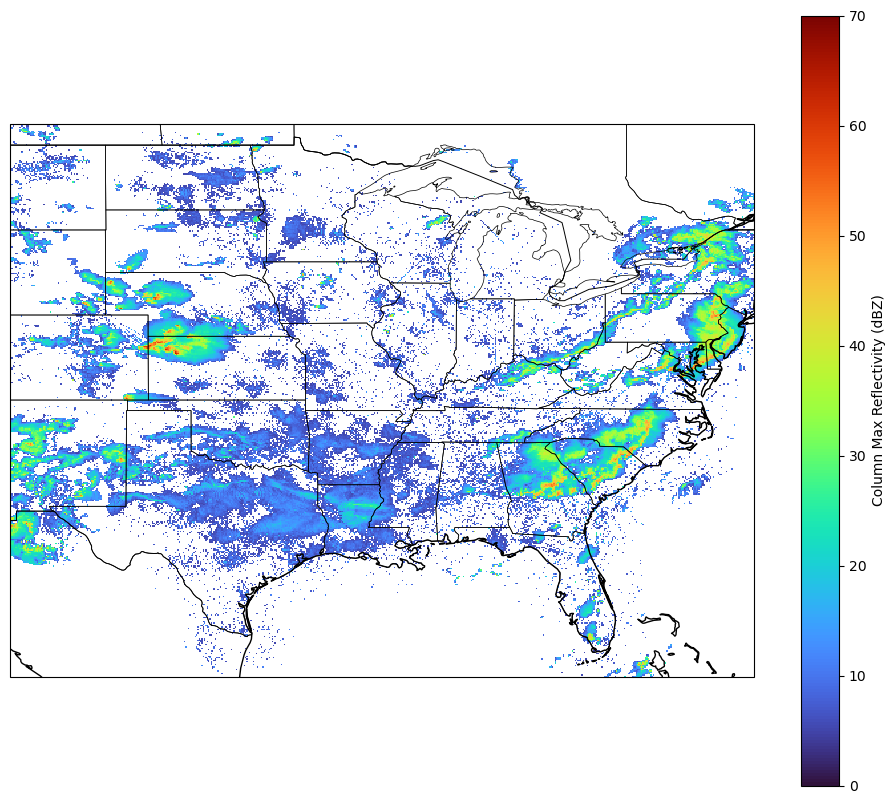

In [6]:
# --- Plot background (Column-Max Reflectivity) ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 10))

# --- Plot background (Column-Max Reflectivity) ---
pcm = ax.pcolormesh(lon_grid, lat_grid, colmax_ds,
                    cmap='turbo', vmin=0, vmax=70, shading='auto',
                    transform=ccrs.PlateCarree())
plt.colorbar(pcm, ax=ax, label="Column Max Reflectivity (dBZ)")

# Map features
ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.5)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.7)
ax.coastlines(resolution='50m')